# 🌸 Iris Flower Classification using Machine Learning

## Oasis Infobyte Data Science Internship

### 📌 Objective
The objective of this project is to build and evaluate machine learning models that can accurately classify Iris flowers into three species (Setosa, Versicolor, and Virginica) based on their physical measurements.

### 👨‍💻 Developed By
**Haseeb Ur Rehman**

### 🛠️ Technologies Used
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Iris Dataset

In [ ]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Dataset Overview

The Iris dataset contains measurements of iris flowers, including sepal length, sepal width, petal length, and petal width. The goal is to classify each flower into one of three species: Setosa, Versicolor, or Virginica.

In [ ]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Dataset Information

In this section, we examine the structure of the dataset, including the data types of each feature and the number of non-null values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Missing Value Analysis

Before training machine learning models, it is important to verify that the dataset does not contain any missing values.

In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


## Descriptive Statistics

The following statistical summary provides information such as the mean, standard deviation, minimum, maximum, and quartile values for each numerical feature.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## Species Distribution

This section shows the number of samples available for each Iris species in the dataset.

In [ ]:
df["species"].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


## Species Distribution Visualization

The following chart visualizes the number of samples belonging to each Iris species.

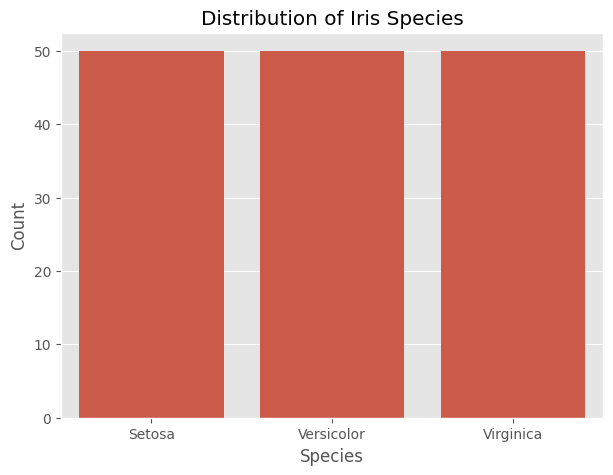

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Pairplot Analysis

The pairplot visualizes the relationship between all numerical features. It helps identify which features best separate the three Iris species.

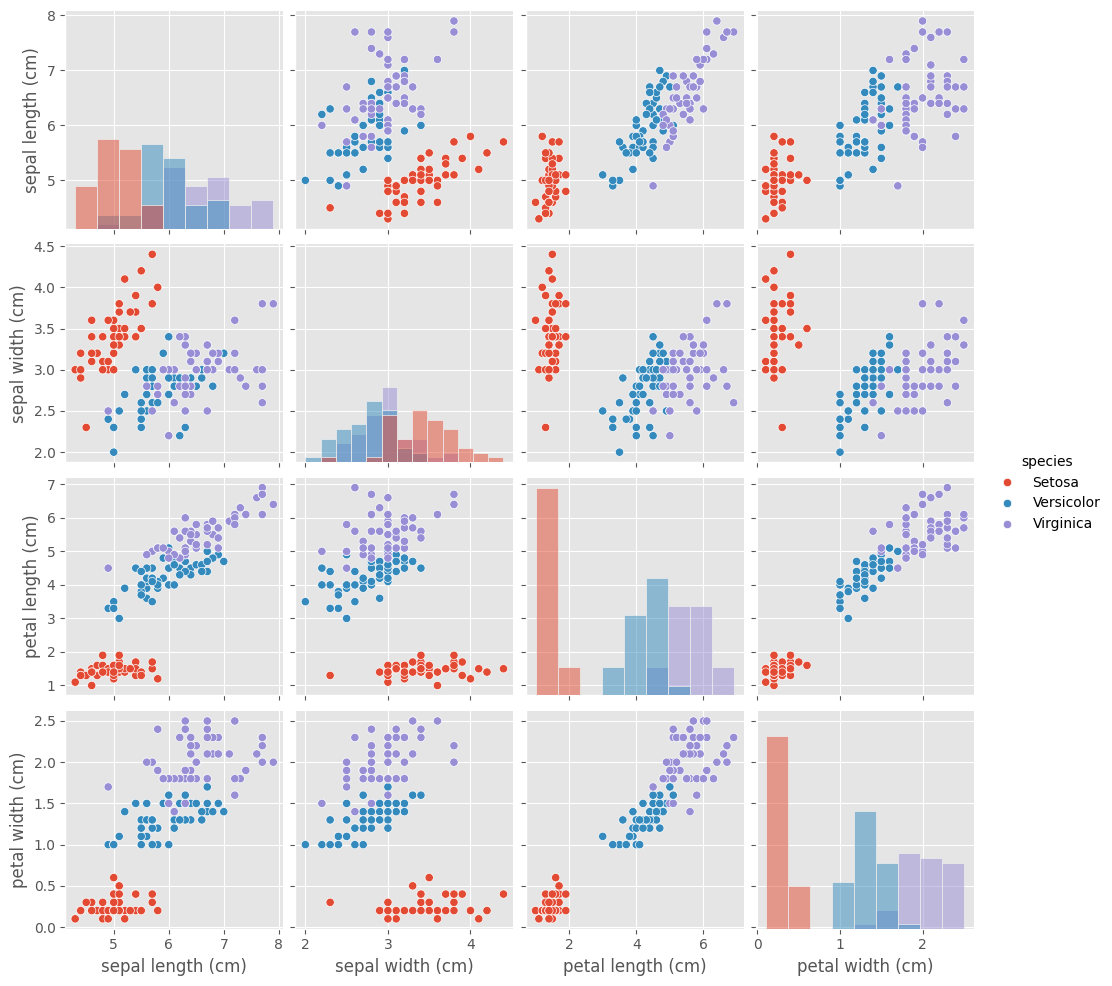

In [ ]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

### Observation

The pairplot shows that **petal length** and **petal width** clearly separate the three Iris species. Setosa is completely distinct, while Versicolor and Virginica have slight overlap.

## Feature Distribution Using Boxplots

Boxplots help identify the distribution of each feature and highlight any potential outliers.

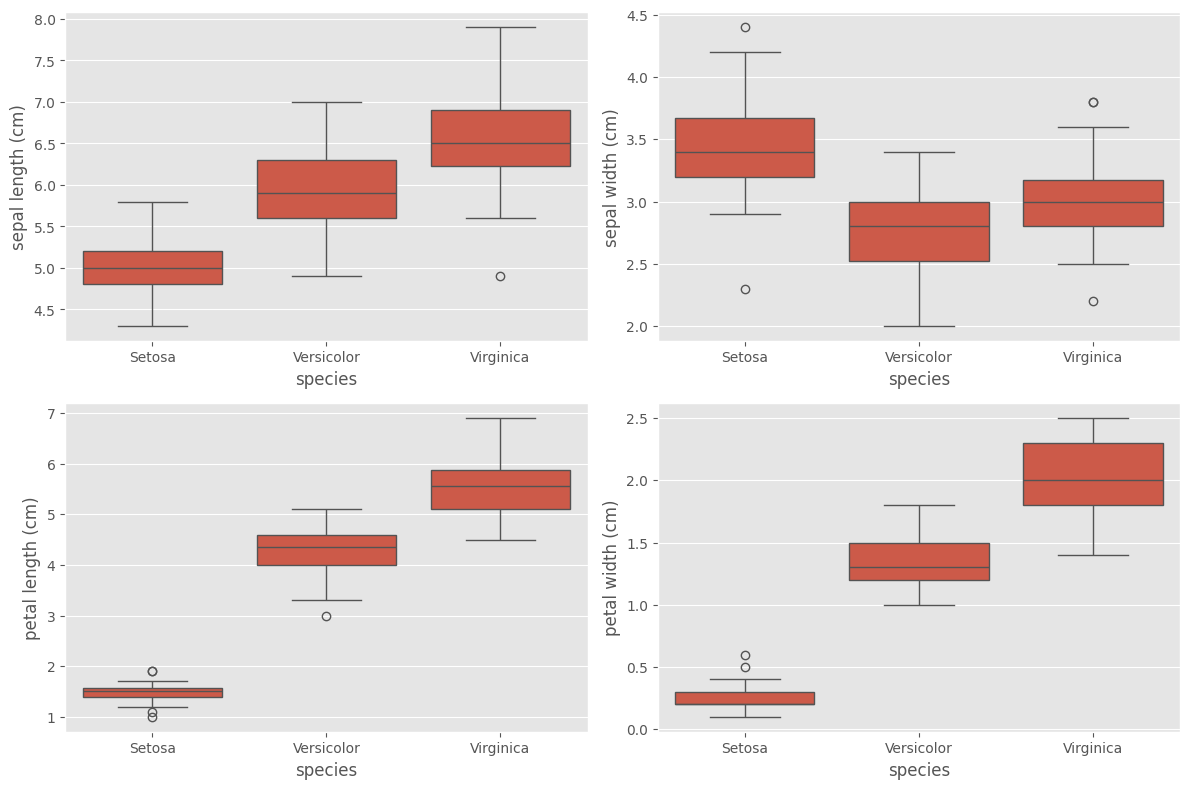

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="species", y="sepal length (cm)", ax=axes[0,0])

sns.boxplot(data=df, x="species", y="sepal width (cm)", ax=axes[0,1])

sns.boxplot(data=df, x="species", y="petal length (cm)", ax=axes[1,0])

sns.boxplot(data=df, x="species", y="petal width (cm)", ax=axes[1,1])

plt.tight_layout()

plt.show()

### Observation

The boxplots indicate that **petal length** and **petal width** provide the clearest separation between species, making them the most useful features for classification.

## Correlation Heatmap

The heatmap illustrates the correlation between numerical features in the dataset.

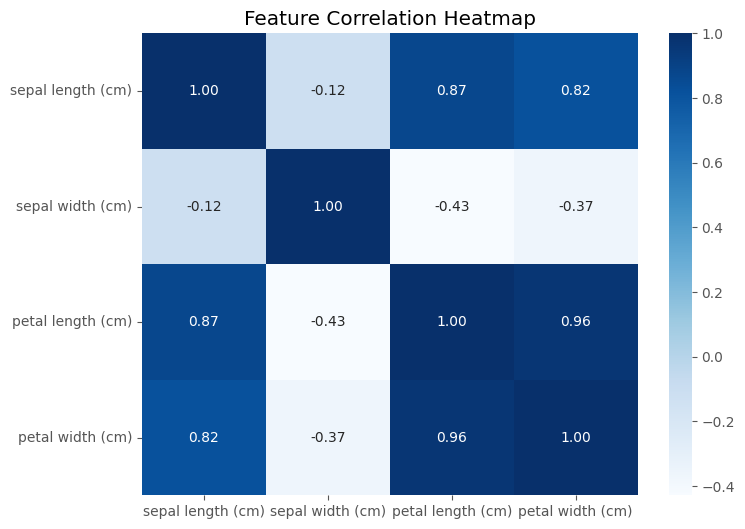

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Feature Selection

Based on the visualizations and correlation analysis, **petal length** and **petal width** are the most discriminative features. These features show clear separation among the three Iris species and contribute significantly to accurate classification.

## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to train the models, while the testing set is used to evaluate their performance.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)

y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


## Model 1: Logistic Regression

Logistic Regression is trained on the Iris dataset and evaluated using accuracy, confusion matrix, and classification report.

Accuracy: 96.67 %


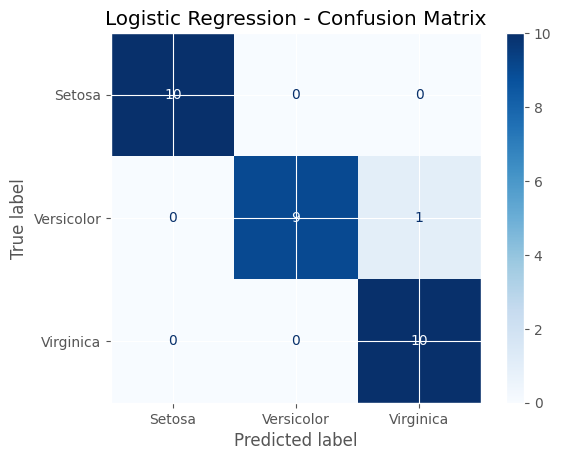

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", round(lr_accuracy*100,2),"%")

ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

print(classification_report(y_test, lr_pred))

## Model 2: K-Nearest Neighbours (KNN)

KNN is evaluated using the same performance metrics for comparison.

Accuracy: 100.0 %


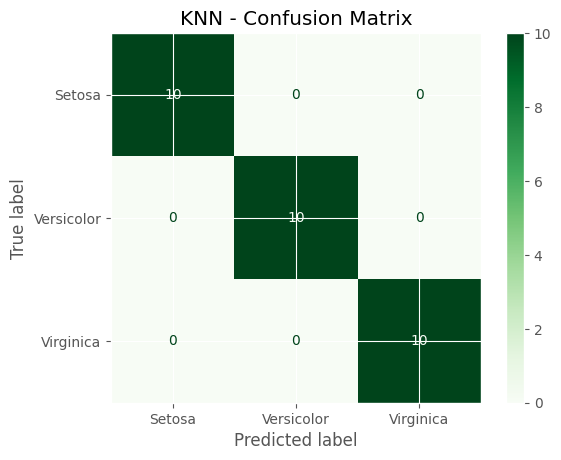

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("Accuracy:", round(knn_accuracy*100,2),"%")

ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("KNN - Confusion Matrix")

plt.show()

print(classification_report(y_test, knn_pred))


## Model 3: Decision Tree

Decision Tree performance is compared with the previous models.

Accuracy: 93.33 %


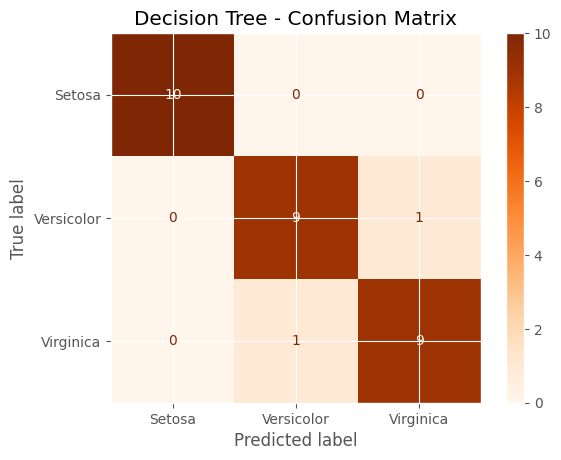

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy:", round(dt_accuracy*100,2),"%")

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Decision Tree - Confusion Matrix")

plt.show()

print(classification_report(y_test, dt_pred))

## Model Comparison

The performance of all trained machine learning models is compared based on their classification accuracy.

In [26]:
comparison.dtypes

,0
Model,object
Accuracy,float64


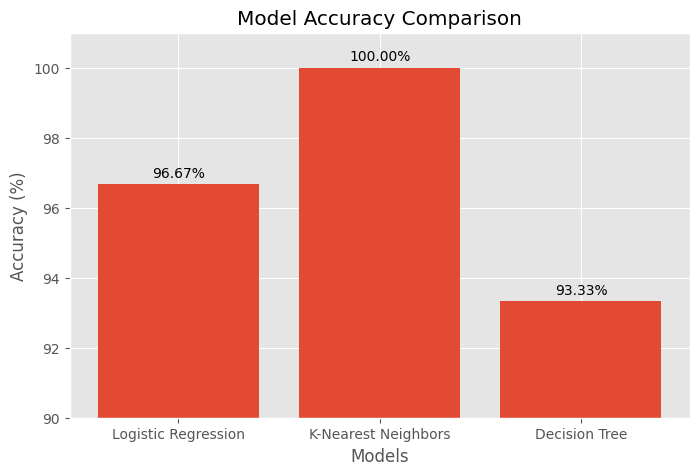

In [27]:
comparison["Accuracy"] = comparison["Accuracy"].astype(float)

plt.figure(figsize=(8,5))

bars = plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(90,101)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha="center"
    )

plt.show()

## Saving the Best Model

The best-performing model is saved so it can be reused later without retraining.

In [28]:
import joblib

joblib.dump(knn, "iris_best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


## Feature Importance

The Decision Tree model provides feature importance scores, showing which measurements contribute most to classification.

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


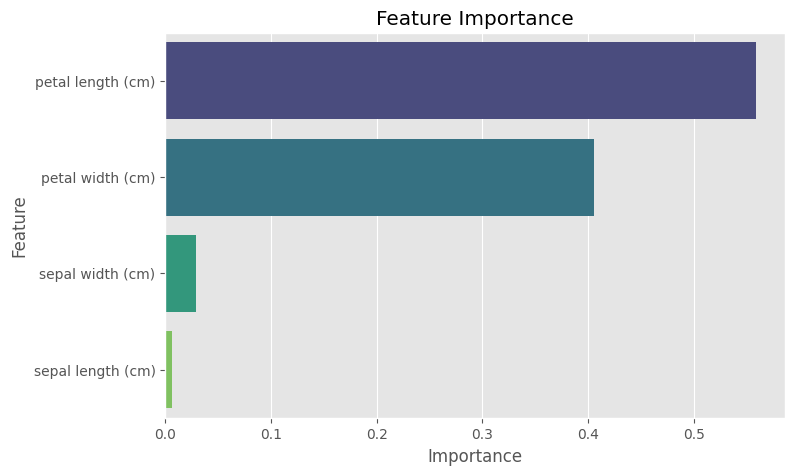

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

## Final Observation

The machine learning models achieved excellent performance on the Iris dataset. Among all features, petal length and petal width were the most influential in distinguishing between species. The selected best model demonstrated outstanding classification accuracy and can reliably predict the species of new Iris flower samples.

# Thank You

**Project Completed Successfully**

**Intern:** Haseeb Ur Rehman

**Organization:** Oasis Infobyte

**Track:** Data Science Internship